<a href="https://colab.research.google.com/github/PedroHON410/Heart-Disease-Predictions-machine-lerarning/blob/main/MLheart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report



# Lendo base de dados

In [ ]:
df = pd.read_csv('heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## Evaluation
Se conseguirmos atingir 95% de precisão em prever se um paciente tem ou não uma doença cardiaca durante o desenvolvimento do modelo, ai continuaremos o nosso projeto

## Atributos
* age: Idade em anos
* sex: sexo (1 = masculino; 0 feminino)
* cp: (dor no peito)
  * 0: Angina típica (dor no peito típica)
  * 1: Angina atípica (dor no peito, não relacionado ao coração)
  * 2: Dor não anginiosa (espasmos, não relacionado ao coração)
  * 3: Assintomático (dor torácica, sem sinais de doença)
* trestbps: pressão arterial em repouso (valores entre 130 - 140 é motivo de preocupação)
* chol: colesterol sérico em mg/dl (acima de 200 é motivo de preocupação)
* fbs: glicemia de jejum > 120 mg/dl (1 = verdadeiro;
0 = falso)
* restecg: resultados do eletrocardiograma em repouso (0: normal;
1: anormalidade; 2: hipertrofia vascular)
* thalach: frequência cardíaca
* exang: Dor enduzida pelo exercício (1: sim; 2: não)
* oldpeak = depressão induzida pelo exercício (observa o estresse do coração durante o exercício)
* slope: Inclinação do segmento do exercício (
Valor 0: ascendente
Valor 1: plano
Valor 2: descendente )
* ca: número de vasos principais (0-3) coloridos por fluorescência (vaso colorido significa que o médico pode ver o sangue passando)
* thal: Resultado do estresse de tálio (
0 = normal
1 = defeito corrigido
2 = defeito reversível)
* target:
0 = sem doença,
1 = doença

## EDA

<Axes: xlabel='target'>

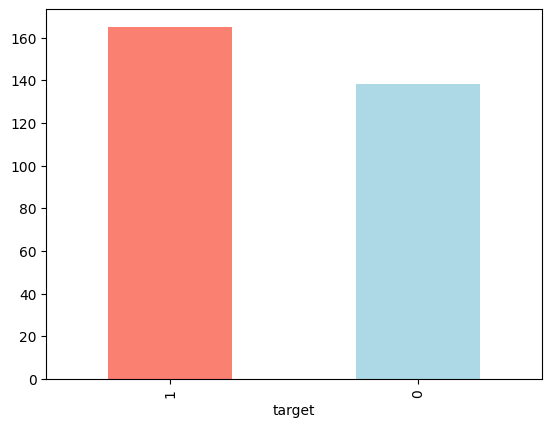

In [ ]:
df['target'].value_counts().plot(kind='bar', color=['salmon', 'lightblue'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### Usando o crosstab retorna um DF de tabulação crusad

In [ ]:
pd.crosstab(df['target'], df['sex'])

sex,0,1
target,,
0,24,114
1,72,93


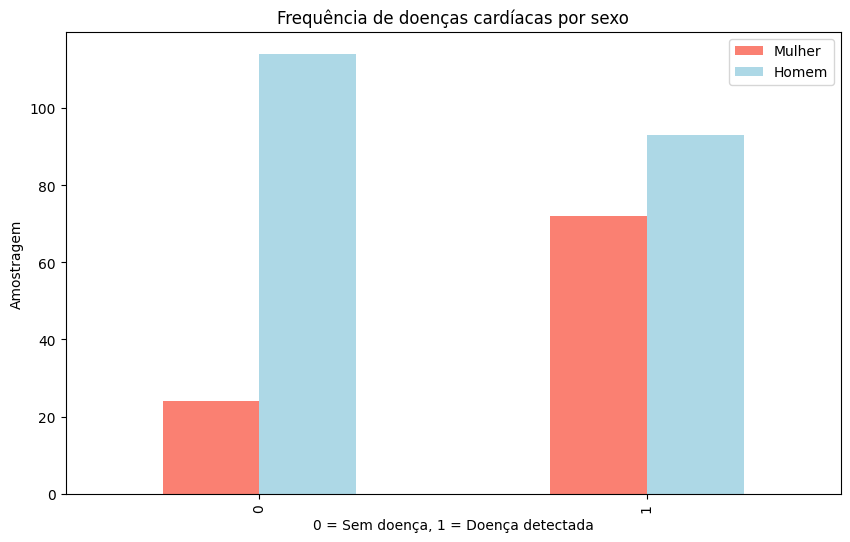

In [ ]:
pd.crosstab(df['target'], df['sex']).plot(kind='bar',
                                          figsize=(10,6),
                                          color=['salmon', 'lightblue'])
plt.title('Frequência de doenças cardíacas por sexo')
plt.xlabel('0 = Sem doença, 1 = Doença detectada')
plt.ylabel('Amostragem')
plt.legend(['Mulher', 'Homem'])

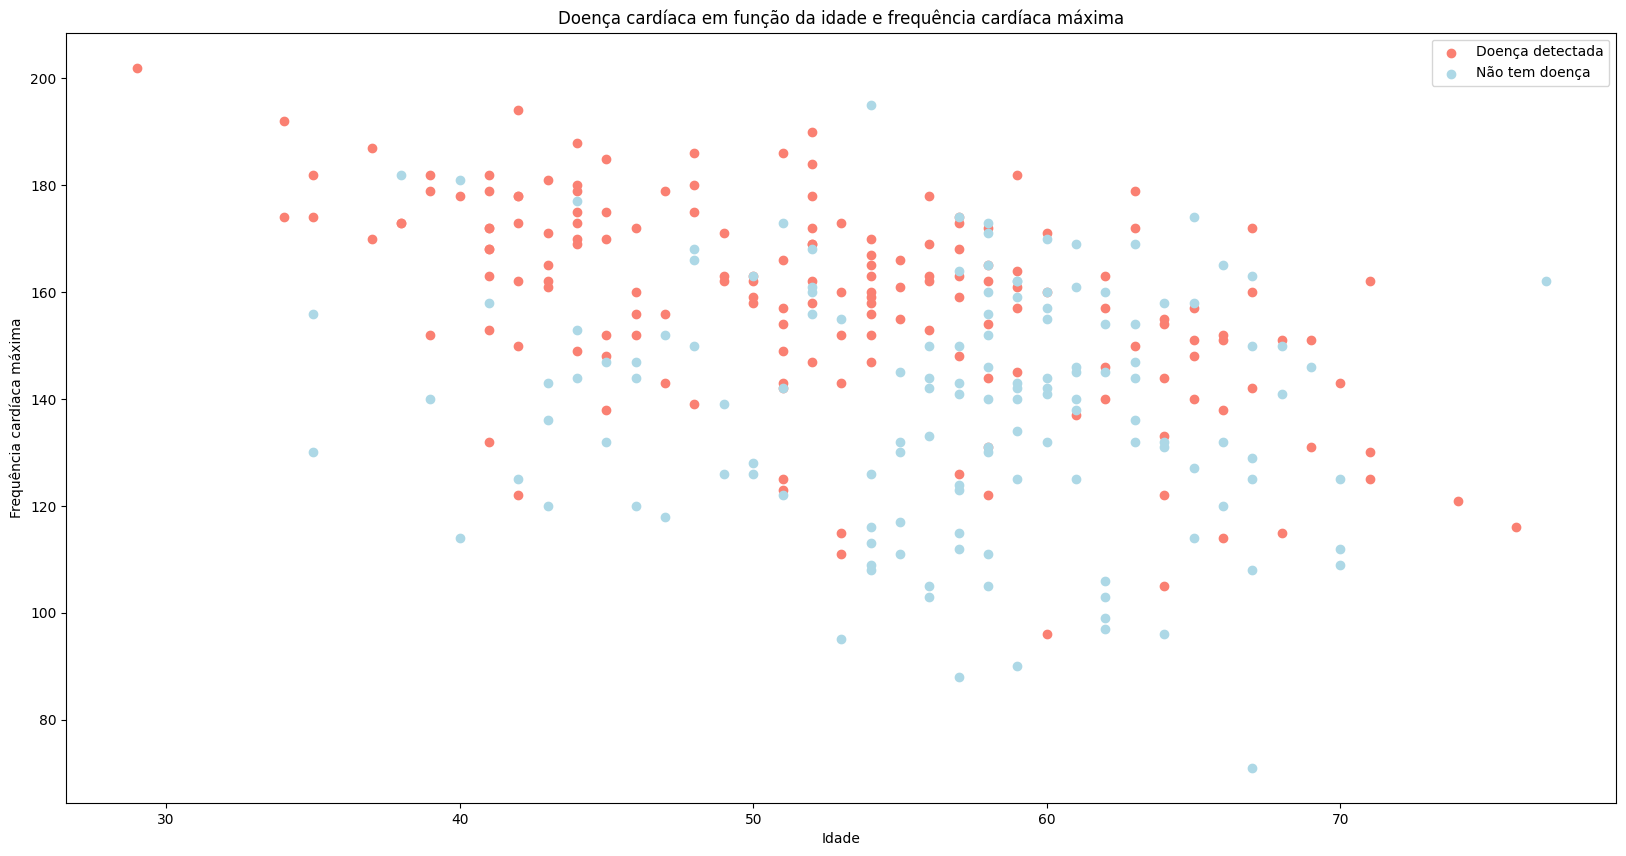

In [ ]:
plt.figure(figsize=(20, 10))

plt.scatter(df['age'] [df['target'] ==1], df['thalach'] [df['target'] ==1], c='salmon')
plt.scatter(df['age'] [df['target'] ==0], df['thalach'] [df['target'] ==0], c='lightblue')

plt.title('Doença cardíaca em função da idade e frequência cardíaca máxima')
plt.xlabel('Idade')
plt.legend(['Doença detectada', 'Não tem doença'])
plt.ylabel('Frequência cardíaca máxima');


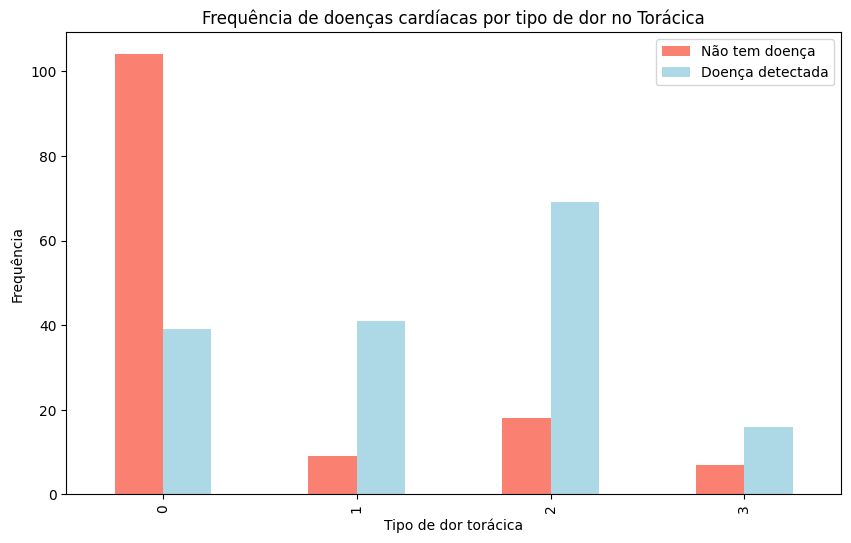

In [ ]:
pd.crosstab(df['cp'], df['target']).plot(kind='bar',
                                          figsize=(10,6),
                                          color=['salmon', 'lightblue'])
plt.title('Frequência de doenças cardíacas por tipo de dor no Torácica')
plt.xlabel('Tipo de dor torácica')
plt.ylabel('Frequência')
plt.legend(['Não tem doença', 'Doença detectada']);

**cp: (dor no peito)**

* **0**: Angina típica (dor no peito típica)
* **1**: Angina atípica (dor no peito, não relacionado ao coração)
* **2**: Dor não anginiosa (espasmos, não relacionado ao coração)
* **3**: Assintomático (dor torácica, sem sinais de doença)

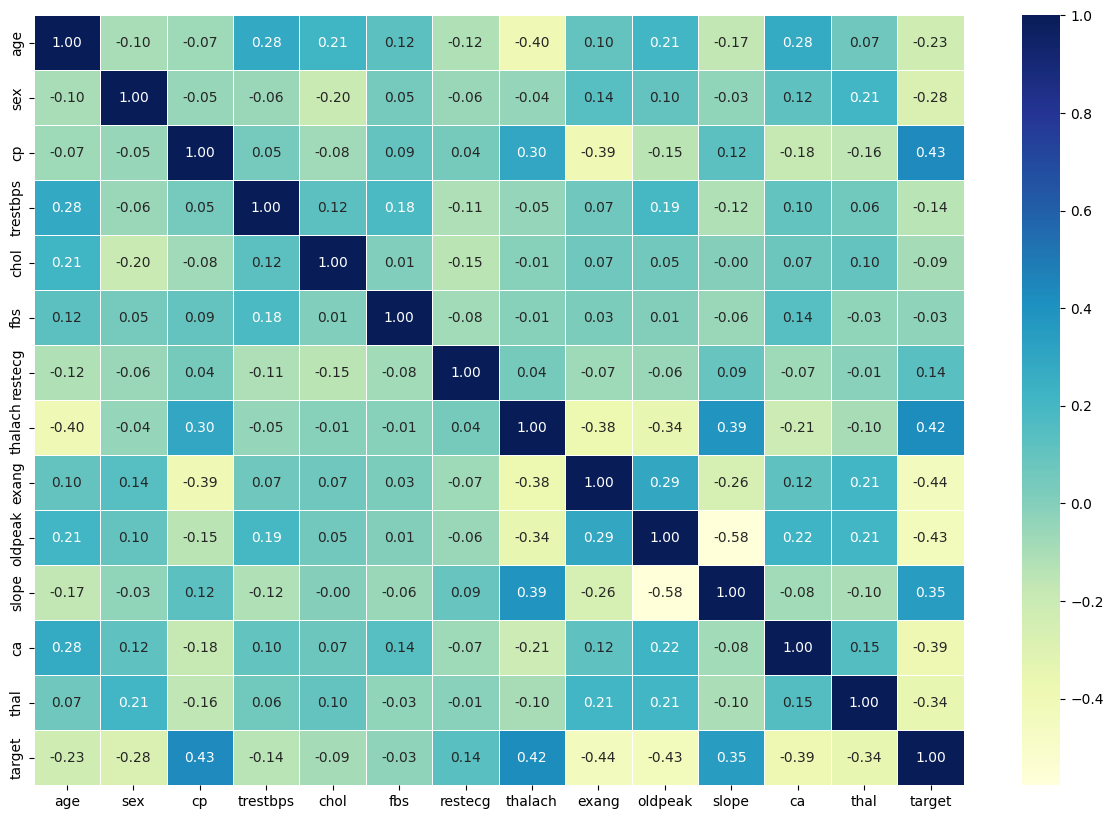

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix,
            annot=True,
            linewidths=0.5,
            fmt=('.2f'),
            cmap='YlGnBu');

## Modelagem dos dados

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

# Treino e Teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
len(X_train), len(y_train)

(242, 242)

In [ ]:
len(X_test), len(y_test)

(61, 61)

In [ ]:
models = {"KNN": KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(),
          "Random Forest": RandomForestClassifier()}
def fit_and_score(models, X_train, X_test, y_train, y_test):
    model_scores= {}

    for name, model in models.items():
        model.fit(X_train, y_train)

        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [ ]:
fit_and_score(models=models,
              X_train=X_train,
              X_test=X_test,
              y_train=y_train,
              y_test=y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.6557377049180327,
 'Logistic Regression': 0.7868852459016393,
 'Random Forest': 0.7704918032786885}

## Ajuste de hiperpâremetros e valizadação cruzada

In [ ]:
train_scores = []
test_cores = []

neighbors = range(1,21)

knn = KNeighborsClassifier()

for i in neighbors:
  knn.set_params(n_neighbors=i)

  knn.fit(X_train, y_train)
  train_scores.append(knn.score(X_train, y_train))
  test_cores.append(knn.score(X_test, y_test))

In [ ]:
train_scores

[1.0,
 0.7933884297520661,
 0.7768595041322314,
 0.7768595041322314,
 0.7520661157024794,
 0.743801652892562,
 0.743801652892562,
 0.7272727272727273,
 0.6942148760330579,
 0.6859504132231405,
 0.6859504132231405,
 0.6694214876033058,
 0.6735537190082644,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058,
 0.6859504132231405,
 0.6611570247933884,
 0.6611570247933884,
 0.6528925619834711]

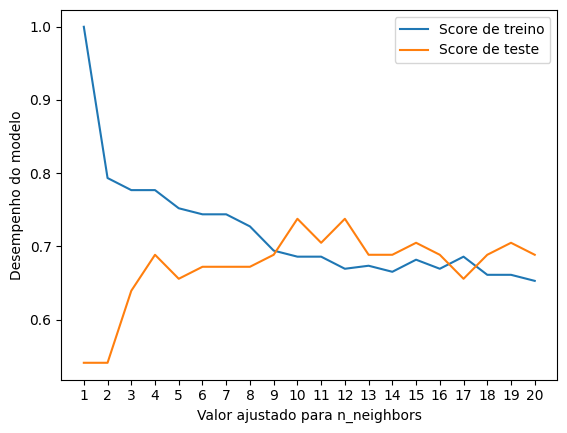

In [ ]:
plt.plot(neighbors, train_scores, label='Score de treino')
plt.plot(neighbors, test_cores, label='Score de teste')
plt.xticks(np.arange(1,21,1))
plt.xlabel('Valor ajustado para n_neighbors')
plt.ylabel('Desempenho do modelo')
plt.legend();

In [ ]:
print(f'Desempenho do modelo de treino: {max(test_cores)*100:.2f}%')

Desempenho do modelo de treino: 73.77%


# Randomizando os dados

In [ ]:
logreg_grid = {"C":np.logspace(-4, 4, 20),
               "solver":['liblinear']}

rf_grid = {"n_estimators":np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split":np.arange(2,20,2),
           "min_samples_leaf":np.arange(1,20,2)}

In [ ]:
rscv_log_reg = RandomizedSearchCV(LogisticRegression(),
                                  param_distributions=logreg_grid,
                                  cv=5,
                                  n_iter=20,
                                  verbose=True)

rscv_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [ ]:
rscv_log_reg.score(X_test, y_test)

0.8032786885245902

In [ ]:
rscv_rf = RandomizedSearchCV(RandomForestClassifier(),
                            param_distributions=rf_grid,
                            cv=5,
                            n_iter=20,
                            verbose=True)

rscv_rf.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
rscv_rf.best_params_

{'n_estimators': np.int64(610),
 'min_samples_split': np.int64(10),
 'min_samples_leaf': np.int64(5),
 'max_depth': 10}

In [ ]:
rscv_rf.score(X_test, y_test)

0.8032786885245902

In [ ]:
gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=logreg_grid,
                          cv=5,
                          verbose=True)

gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
gs_log_reg.best_params_

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [ ]:
gs_log_reg.score(X_test, y_test)

0.8032786885245902

# Avaliando o modelo

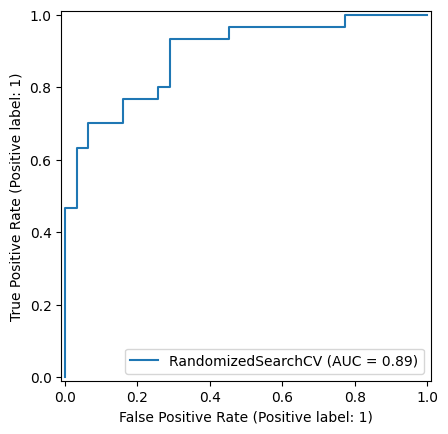

In [ ]:
RocCurveDisplay.from_estimator(rscv_rf, X_test, y_test);


In [ ]:
y_prends = rscv_rf.predict(X_test)


In [ ]:
y_prends

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [ ]:
np.array(y_test)

array([1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1])

In [ ]:
print(confusion_matrix(y_test, y_prends))

[[21 10]
 [ 2 28]]


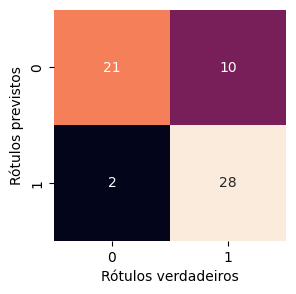

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test, y_prends),
               annot=True,
               cbar=False)
plt.xlabel('Rótulos verdadeiros');
plt.ylabel('Rótulos previstos');

# Relatório de classificação

In [ ]:
print(classification_report(y_test, y_prends))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78        31
           1       0.74      0.93      0.82        30

    accuracy                           0.80        61
   macro avg       0.82      0.81      0.80        61
weighted avg       0.83      0.80      0.80        61

